# Regression Metrics

- It is important to evaluate the performance of our regression model using appropriate metrics. Some commonly used regression metrics include:

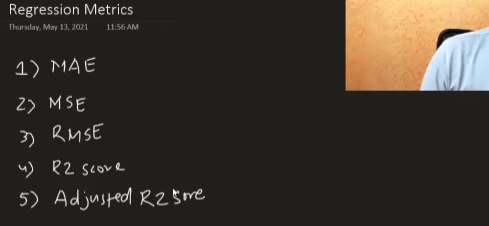

# MAE: Mean Absolute Error

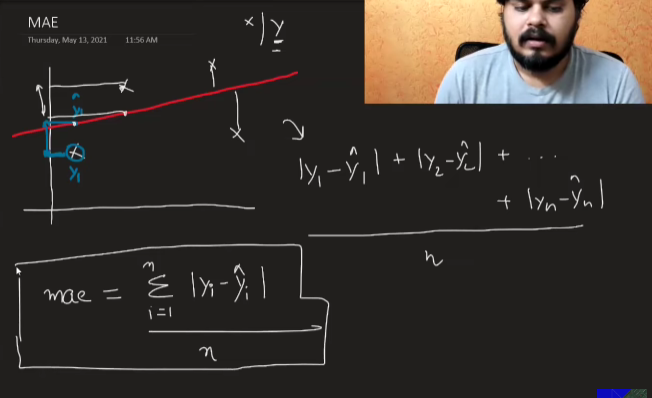

- It is basically the loss, humare jo regression alog hoga uska kaam hoga ise kmse km krna

## Advantages of MAE:

- Units are the same as the target variable, making it easy to interpret.
- It's robust to outliers (means it doesn't penalize large errors as heavily), as it does not square the errors.

## Disadvantages of MAE:

- Modulus function is not differentiable at zero, which can make optimization more difficult.

# MSE: Mean Squared Error

- In our previous SLR implementation, we were using MSE as our loss function, and we were trying to minimize it to find the best fit line.

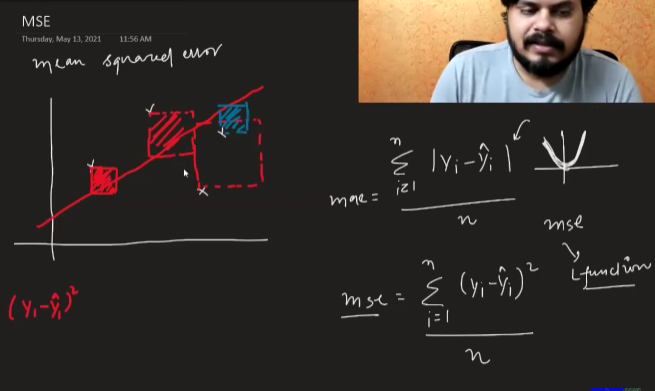

## Advantages of MSE:

- It can be used as a loss function for optimization algorithms, as it is differentiable.

## Disadvantages of MSE:

- Units are the square of the target variable, which can make it less interpretable.
- It penalizes the outliers more, so not robust to outliers (means MSE explodes with outliers).

- If there are lots of outliers in the data, then MAE might be a better choice than MSE, otherwise MSE is generally preferred as it is easier to optimize.

# RMSE: Root Mean Squared Error

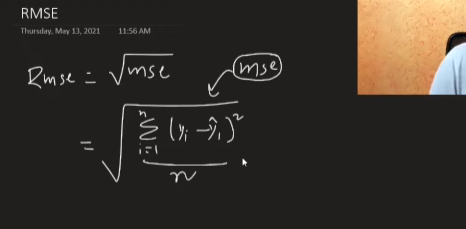

# Advantages of RMSE:
- It is in the same units as the target variable, making it more interpretable than MSE.

# Disadvantages of RMSE:
- Like MSE, it is also sensitive to outliers, as it penalizes large errors more heavily than smaller errors.

### <span style="color:orange">Since we are begginer at this stage, so if you are doing regression analysis, then teeno nikal k dekh lo</span> 

- So these 3 metrices are context dependent, for example if you are working with pagkage, then let's say any of the 3 metrics is 1.5 lakh, then this much error is fine, but let say you are looking for car steering angle for accident prevention, then error of even 1.5 degree can be fatal

- So while judging the performance of your regression model, you should always keep in mind the context of the problem you are trying to solve, and choose the appropriate metric accordingly.

- Let's see some more metrices that gives some absolute measure of the performance of our regression model, like R-squared, Adjusted R-squared, etc. 

# R2 Score / Coefficient of Determination /Goodness of Fit

- Maanlo aapke paas bs package ka data hota, and cgpa nhi hota, and koi aapse aake puchta ki whats the placement of this college, so the best thing you could do is average out the packages and tell them that.

- But as we have the data of the cgpa as well, so we can do better than that, we can use the cgpa to predict the package, and we can do that using linear regression

- So when we find out R2 score it ba sically compares <span style="color:orange">How much better is the line our model has fit compared to a horizontal line (the mean)</span>

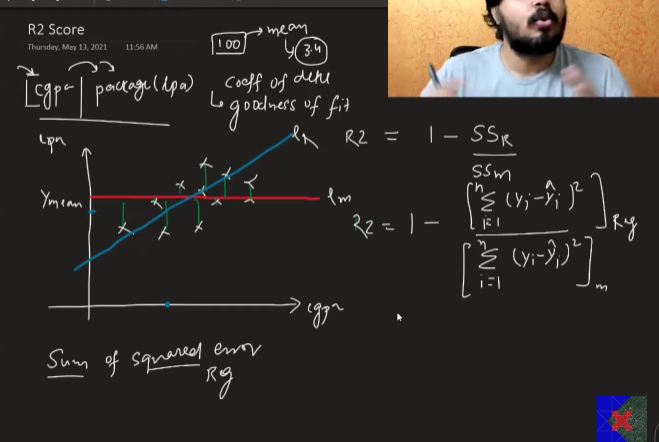


# Interpretation of R2 Score:

- If R2 score is 0, It means that our model is no better than the horizontal line (the mean)

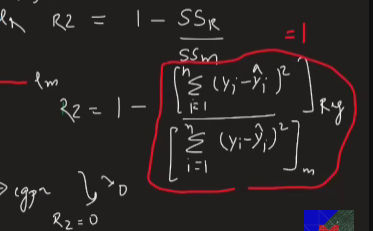

- If R2 score is 1, It means humara model koi galti hi nhi kr rha (Because the numerator of the 2nd term (SSR) will be 0), which means that our model is perfectly fitting the data

- <span style="color:orange">So try kro ki R2 score 1 ki taraf jaye </span>

### What if R2 score is negative?

- It means SSR > SSM, which means that our model is doing worse than the horizontal line (the mean), which means that our model is not fitting the data at all, and it is doing worse than just predicting the mean for all the data points.

- It means aapne aake data ko samjha hi nhi dhang se, for example your data is highly non-linear, and you are trying to fit a linear model to it, then you will get a negative R2 score, which means that your model is doing worse than just predicting the mean for all the data points.

## <span style="color:orange">Another Interpretation of R2 Score</span>

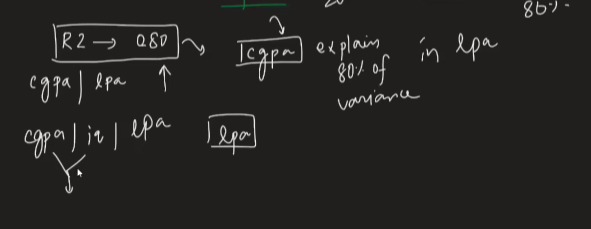

- If R2 score is 0.8 for the case in the above image, it means that our model is able to explain 80% of the variance in the target variable(package), and the remaining 20% of the variance is due to other factors that are not captured by our model (that we don't know about).

# Advantages of R2 Score:

- It is context independent, which means that it can be used to compare the performance of different models on the same dataset

# Disadvantages of R2 Score:

- As we increase no. of features in our model the R2 sore increases as we can interpret it as the no. of features increases the model is able to explain more variance in the target variable. And this thing is fine as well if the columns are relevant to the target variable

- But suppose a column like temperature (Obviously its not relevant to the target variable) is added along with the cgpa, so sometimes the R2 score increases or remains the same, whereas it should have decreased. **So to handle this problem we have another metric called Adjusted R2 Score**

# Adjusted R2 Score

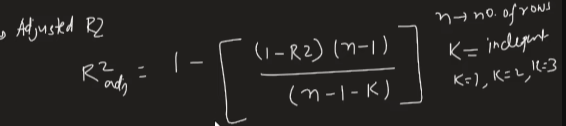

- for 't' input column k= t (Eg. if we have cgpa,temperature, iq, then k=3)

- This formula is designed in such a way that it eliminates the flaw of R2 score

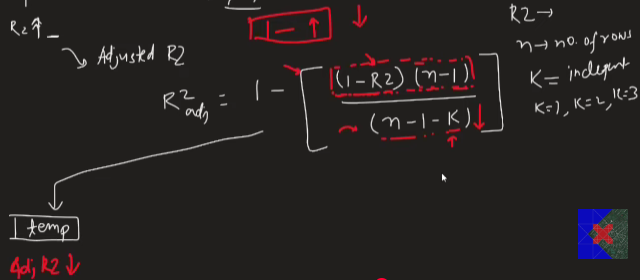

- As the number of features (k) increases, the denominator of the 2nd term decreased, and the numerator remains almost same or slightly increases (as the addition of irrelevant features may not increase the explained variance much), so the 2nd term increases, which means that the Adjusted R2 score decreases, which is what we want.

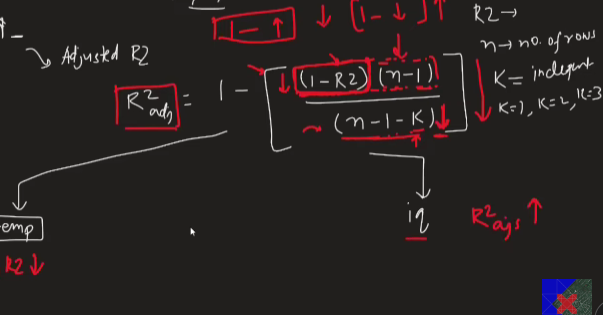

- Here for relevant column, the denominator of the 2nd term decreases, and the numerator R2 increases significantly, so the 2nd term decreases overall, which means that the Adjusted R2 score increases, which is what we want.

- Useful for multiple linear regression
- Kaide se aapko dono nikal k dekhna chahiye, if there is difference between the two, then you should prefer Adjusted R2 Score over R2 Score, otherwise R2 Score is fine as well.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [43]:
df = pd.read_csv('placement.csv')

In [44]:
df.head()
df.shape

(200, 2)

Text(0, 0.5, 'Package(in lpa)')

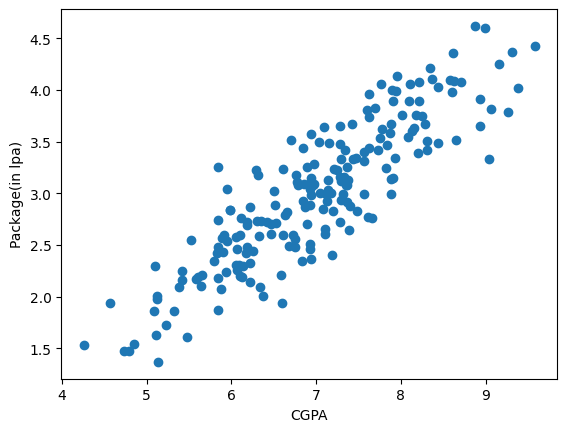

In [45]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [46]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [47]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [48]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [49]:
from sklearn.linear_model import LinearRegression

In [50]:
lr = LinearRegression()

In [51]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Text(0, 0.5, 'Package(in lpa)')

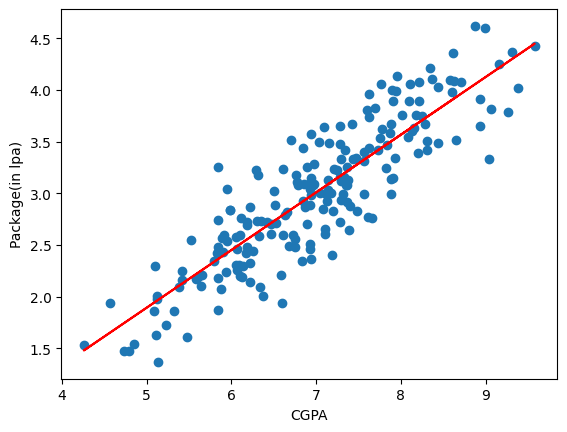

In [52]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [53]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [54]:
y_pred = lr.predict(X_test)

In [55]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [56]:
print("MAE",mean_absolute_error(y_test,y_pred))  # in lpa

MAE 0.2884710931878175


- i.e humara model 0.28 lpa ki galti kar raha hai

In [57]:
print("MSE",mean_squared_error(y_test,y_pred)) # in lpa^2

MSE 0.12129235313495527


In [58]:
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred))) # in lpa, it is more interpretable than MSE

RMSE 0.34827051717731616


In [59]:
print("R2 Score:",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 Score: 0.780730147510384


- It means the Cgpa column can explain 80.8% of the variance in the package, and the remaining 19.2% of the variance is due to other factors that are not captured by our model (that we don't know about).

In [60]:
# Adjusted R2 score
X_test.shape

(40, 1)

In [61]:
1 - ((1-r2)*(40-1)/(40-1-1))

0.7749598882343415

- very close to R2 score

## Let's add a random column called 'iq' to our dataset, and see how it affects the R2 score and Adjusted R2 score.

In [62]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)

new_df1 = new_df1[['cgpa','random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.663134,3.26
1,5.12,0.194546,1.98
2,7.82,0.544947,3.25
3,7.42,0.537658,3.67
4,6.94,0.861757,3.57


Text(0, 0.5, 'Package(in lpa)')

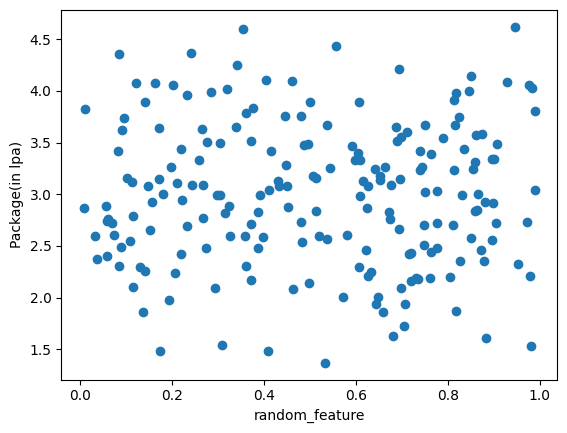

In [63]:
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('Package(in lpa)')

In [64]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]

In [65]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [66]:
lr = LinearRegression()

In [67]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [68]:
y_pred = lr.predict(X_test)

In [69]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.7772003784602107


In [70]:
1 - ((1-r2)*(40-1)/(40-1-2))

0.7651571556742762

## Lets add a new column called 'iq' to our dataset, and see how it affects the R2 score and Adjusted R2 score.

In [71]:
new_df2 = df.copy()

new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10)

new_df2 = new_df2[['cgpa','iq','package']]

In [72]:
new_df2.sample(5)

,cgpa,iq,package
172,6.93,3.01,2.51
69,7.30,2.84,2.94
142,6.93,2.04,3.04
74,6.85,3.44,3.44
153,7.94,2.79,3.99


Text(0, 0.5, 'Package(in lpa)')

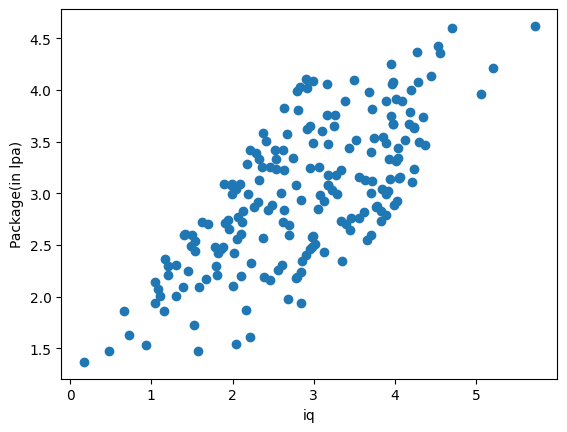

In [73]:
plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('iq')
plt.ylabel('Package(in lpa)')

In [74]:
np.random.randint(-100,100)

26

In [75]:
X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]

In [76]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [77]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

In [78]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.8402927613021506


In [79]:
1 - ((1-r2)*(40-1)/(40-1-2))

0.8316599375887533

# <span style="color:orange">Adjusted R2 Score is more helpful when number of features is more </span>